In [1]:
# 安装quarkstudio(pip install quarkstudio)
from quark import Task

In [ ]:
# 获取token，如果在进入jupyter环境之前已经有有效的API token，这一行不需要
token = "9fWCWDySBDeP8m4{mFqW[L2zMdt54g6uUk.FgUlJLfI/:mENxNUN{RkM1VUO{FkN2N{OypkJxiY[jxjJ1VkP2RkP6FEJ3JUMyFUM1JENzJjPjRYZqKDMj53ZvNXZvNYbyGnZBWo[iWYdjpkJzW3d2Kzf"

In [ ]:
# 实例化任务管理器，如果在进入jupyter环境之前已经有有效的API token，实例化任务管理器可以不传递token参数
tmgr = Task()

In [4]:
# 查看可用芯片及当前状态
tmgr.status()

{'Dongling': 'Maintenance',
 'Miaofeng': 'Maintenance',
 'Baihua': 57,
 'Yunmeng': 'Maintenance',
 'Haituo': 'Maintenance'}

Baihua configuration loading done!
The last calibration time was 2024-12-12 10:09:49


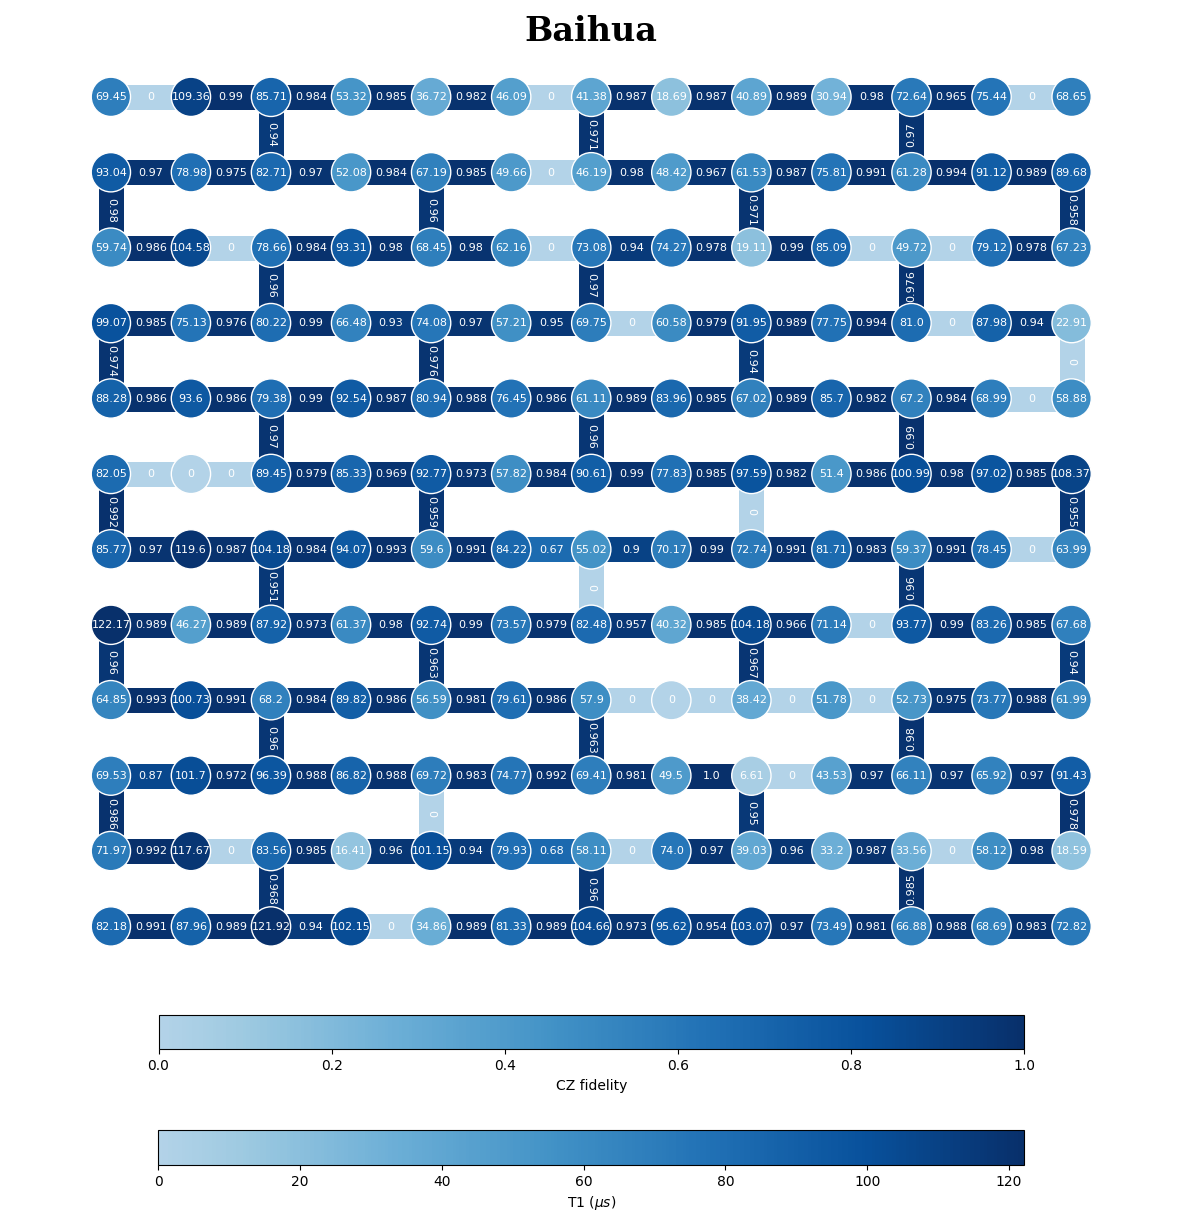

In [5]:
# 获取指定芯片信息
info = tmgr.backend(
    "Baihua", show_couplers_fidelity=True, show_quibts_attributes="T1", save_svg_fname="test"
)

In [ ]:
# 利用qiskit or quarkcircuit生成通用OpenQASM 2.0 线路
# example1: Qiskit
from qiskit import QuantumCircuit as qiskitQC
from qiskit import qasm2

qc = qiskitQC(8, 8)
qc.h(2)
for i in range(2, 6):
    qc.cx(i, i + 1)
qc.measure(2, 0)
qc.measure(3, 1)
qc.measure(4, 2)
qc.measure(5, 3)
print(qasm2.dumps(qc))
# qc.draw()

OPENQASM 2.0;
include "qelib1.inc";
qreg q[8];
creg c[8];
h q[2];
cx q[2],q[3];
cx q[3],q[4];
cx q[4],q[5];
cx q[5],q[6];
measure q[2] -> c[0];
measure q[3] -> c[1];
measure q[4] -> c[2];
measure q[5] -> c[3];


In [21]:
# example2: quarkcircuit
from quark.circuit import QuantumCircuit as quarkQC

qc = quarkQC(8, 8)
qc.h(2)
for i in range(2, 6):
    qc.cx(i, i + 1)
qc.measure(2, 0)
qc.measure(3, 1)
qc.measure(4, 2)
qc.measure(5, 3)
print(qc.to_openqasm2)
# qc.draw()

OPENQASM 2.0;
include "qelib1.inc";
qreg q[8];
creg c[8];
h q[2];
cx q[2],q[3];
cx q[3],q[4];
cx q[4],q[5];
cx q[5],q[6];
measure q[2] -> c[0];
measure q[3] -> c[1];
measure q[4] -> c[2];
measure q[5] -> c[3];


In [ ]:
# 生成任务线路
qasm = """
OPENQASM 2.0;
include "qelib1.inc";
qreg q[8];
creg meas[8];
h q[2];
cx q[2],q[3];
cx q[3],q[4];
cx q[4],q[5];
measure q[2] -> meas[0];
measure q[3] -> meas[1];
measure q[4] -> meas[2];
measure q[5] -> meas[3];
"""

In [ ]:
task = {
    "chip": "Baihua",  # chip name
    "name": "MyQuantumnTask",  # task name
    "circuit": qasm,  # qasm
    "compile": True,
}

In [19]:
tid = tmgr.run(task)

In [1]:
# tmgr.cancel(tid)

In [20]:
tmgr.status(tid)

'Submitted'

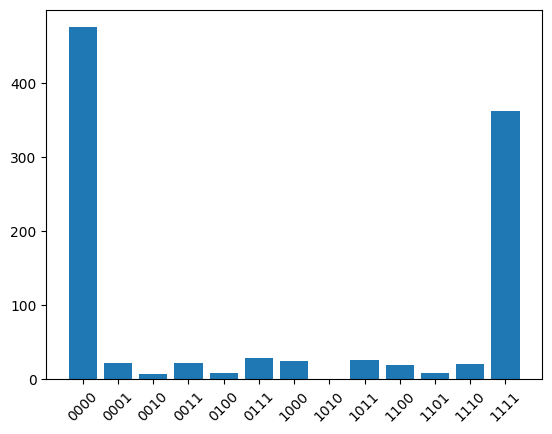

In [15]:
# 获取结果并绘图
import matplotlib.pyplot as plt

res = tmgr.result(tid)
data = res["count"]
bases = sorted(data)
count = [data[base] for base in bases]

plt.bar(bases, count)
ticks = plt.xticks(rotation=45)